### Import Dependencies

In [1]:
import json
from pathlib import Path
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

### The Idea

**PPDA** (*Passes allowed Per Defensive Action*), from Colin Trainor, proxies **pressing intensity**: how many passes a side lets its opponent string together before it challenges for the ball.

$$
\text{PPDA} = \frac{\text{opponent passes}}{\text{tackles} + \text{interceptions} + \text{challenges} + \text{fouls}}
$$

A **lower** PPDA means a **more intense** press. Both counts are restricted to the **opponent's defensive 60%** of the pitch — the build-up zone where pressing happens — so opponent passes in their attacking 40%, where challenges are last-ditch defending rather than pressing, don't dilute it.

We build the metric on **StatsBomb Open Data** — La Liga **2015/2016**, with **Barcelona** as the focal team.

### Loading a Season

Each StatsBomb event carries a `type`, the acting `team`, an `[x, y]` `location`, the `minute`, and the `period`. We start from the season's match list (for team names and match week), then load every match's events in parallel, keeping only the types PPDA needs: `Pass` for the numerator; `Duel` (tackles), `Interception`, `Dribbled Past` and `Foul Committed` for the denominator.

In [2]:
SB = Path("/path/to/your/statsbomb/data")  # Change this to your StatsBomb data path
COMP_ID, SEASON_ID = 11, 27          # La Liga 2015/2016
FOCAL_TEAM = "Barcelona"

matches_raw = json.load(open(SB / "matches" / str(COMP_ID) / f"{SEASON_ID}.json"))
matches = pd.DataFrame([
    {
        "match_id": m["match_id"],
        "home": m["home_team"]["home_team_name"],
        "away": m["away_team"]["away_team_name"],
        "match_week": m["match_week"],
        "date": m["match_date"],
    }
    for m in matches_raw
])

print(f"{len(matches)} matches, {len(set(matches.home) | set(matches.away))} teams")

380 matches, 20 teams


In [3]:
KEEP_TYPES = {"Pass", "Duel", "Interception", "Foul Committed", "Dribbled Past"}


def load_events(match_id):
    with open(SB / "events" / f"{match_id}.json") as fp:
        raw = json.load(fp)

    rows = []
    for e in raw:
        t = e["type"]["name"]
        if t not in KEEP_TYPES:
            continue
        x, y = (e.get("location") or [None, None])[:2]
        rows.append(
            {
                "match_id": match_id,
                "team": e["team"]["name"],
                "type": t,
                "duel_type": e.get("duel", {}).get("type", {}).get("name"),
                "x": x,
                "y": y,
                "minute": e.get("minute"),
                "period": e.get("period"),
            }
        )
    return pd.DataFrame(rows)


print(f"Loading events from {len(matches)} matches...")
with Pool(cpu_count()) as pool:
    parts = list(pool.imap(load_events, matches["match_id"]))

events = pd.concat(parts, ignore_index=True)
print(f"Loaded {len(events):,} events from {events['match_id'].nunique()} matches")

Loading events from 380 matches...


Loaded 430,222 events from 380 matches


### Computing PPDA

The press lives in one band — the opponent's defensive 60% — but StatsBomb normalizes every team to attack towards `x = 120`, so the two teams see that band mirrored:

- a **pressing** team's defensive action counts when `x > 48` (its attacking 60%);
- the **pressed** team's pass counts when `x < 72` (the same band, near its own goal).

$$
x_{\text{press}} = 120 - x_{\text{opponent}}
$$

A `Duel` counts only when its sub-type is `Tackle`; a `Foul Committed` is a defensive action for the team that gave it away. We flag every event, aggregate to `(match, team)`, and — since a match has two teams — a team's **opponent passes** is the match total minus its own. PPDA is opponent passes over the team's own defensive actions.

In [4]:
PITCH_LENGTH, PITCH_WIDTH = 120.0, 80.0
DEF_ACTION_MIN_X = 0.40 * PITCH_LENGTH        # 48.0
PASS_MAX_X = PITCH_LENGTH - DEF_ACTION_MIN_X  # 72.0

is_tackle = (events["type"] == "Duel") & (events["duel_type"] == "Tackle")
is_def_action = is_tackle | events["type"].isin(["Interception", "Foul Committed", "Dribbled Past"])
is_pass = events["type"] == "Pass"

events["pass_in_zone"] = is_pass & (events["x"] < PASS_MAX_X)
events["def_action_in_zone"] = is_def_action & (events["x"] > DEF_ACTION_MIN_X)

In [5]:
team_match = (
    events
    .groupby(["match_id", "team"])
    .agg(
        passes=("pass_in_zone", "sum"),
        def_actions=("def_action_in_zone", "sum"),
    )
    .reset_index()
)

match_passes = team_match.groupby("match_id")["passes"].transform("sum")
team_match["opp_passes"] = match_passes - team_match["passes"]
team_match["ppda"] = team_match["opp_passes"] / team_match["def_actions"]
team_match = team_match.replace([np.inf, -np.inf], np.nan).dropna(subset=["ppda"])

### Sanity Check: a Single Match

Before reading season-wide stories from PPDA, confirm it behaves on one familiar game. We print both sides' PPDA with the raw counts: the ball-dominant presser should post a low number, a deep-block opponent a high one.

In [6]:
def ppda_for_match(match_id):
    rows = team_match[team_match["match_id"] == match_id]
    info = matches[matches["match_id"] == match_id].iloc[0]
    print(f"PPDA — {info['home']} vs {info['away']} (week {info['match_week']})")
    for _, r in rows.iterrows():
        print(
            f"  {r['team']:<16} PPDA={r['ppda']:6.2f}  "
            f"(opp passes={int(r['opp_passes'])}, def actions={int(r['def_actions'])})"
        )


focal_opener = (
    matches[(matches["home"] == FOCAL_TEAM) | (matches["away"] == FOCAL_TEAM)]
    .sort_values("match_week")["match_id"].iloc[0]
)
ppda_for_match(focal_opener)

PPDA — Athletic Club vs Barcelona (week 1)
  Athletic Club    PPDA= 16.29  (opp passes=619, def actions=38)
  Barcelona        PPDA= 10.70  (opp passes=246, def actions=23)


### Who Presses Hardest?

Pooling every match a team played gives its season **pressing identity**: total opponent passes over total defensive actions. The chart ranks all 20 sides from most to least aggressive (lowest PPDA first), with **Barcelona** highlighted.

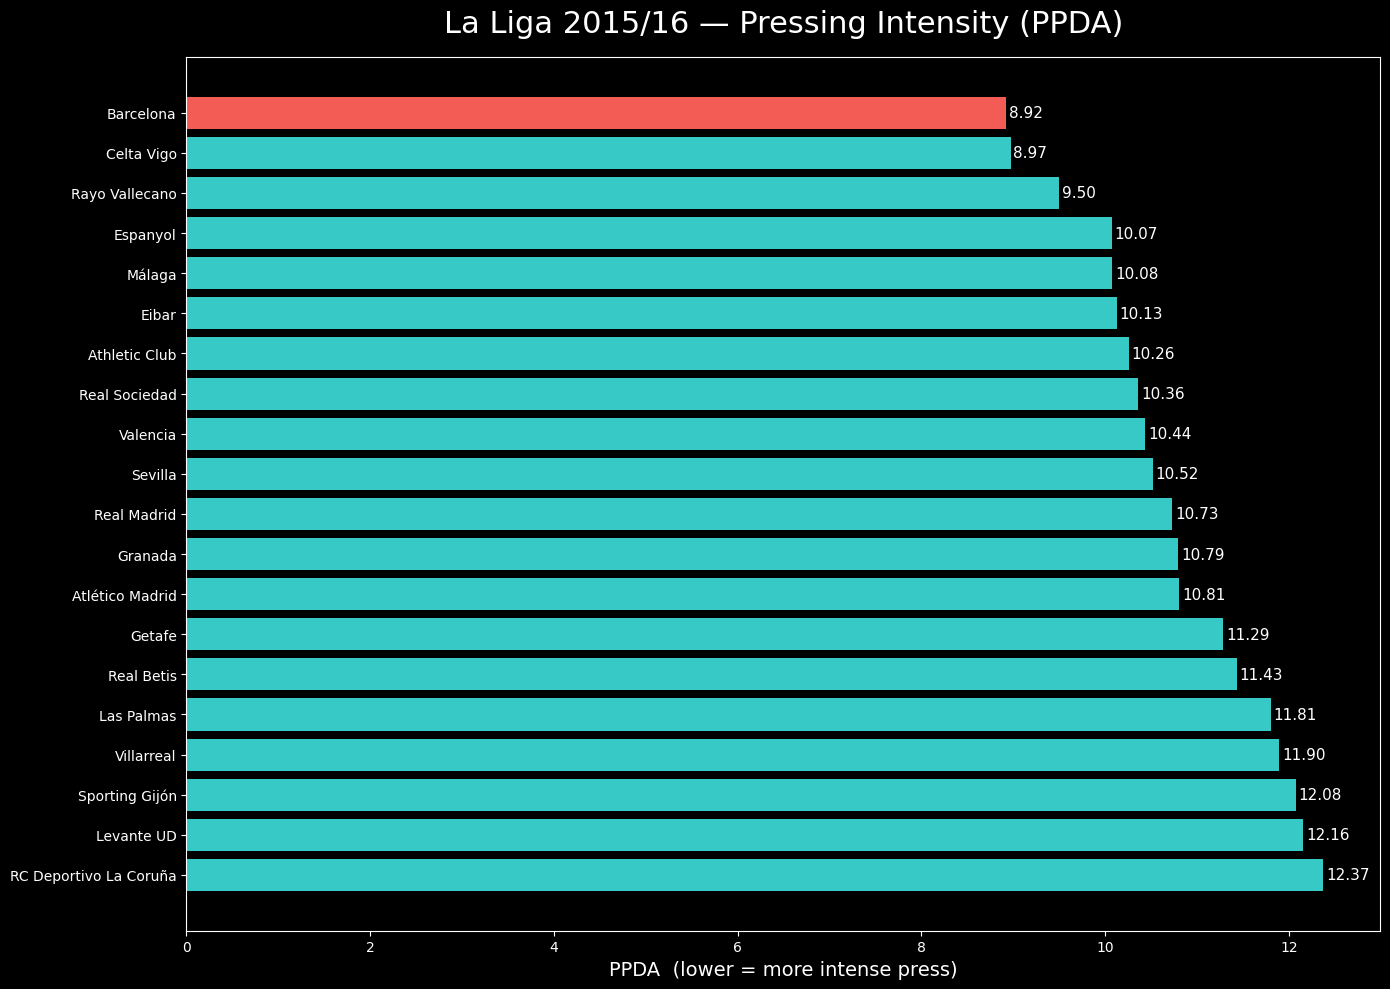

In [7]:
team_season = (
    team_match
    .groupby("team")
    .agg(opp_passes=("opp_passes", "sum"), def_actions=("def_actions", "sum"))
    .reset_index()
)
team_season["ppda"] = team_season["opp_passes"] / team_season["def_actions"]
team_season = team_season.sort_values("ppda").reset_index(drop=True)

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(14, 10))
colors = ["#f25c54" if t == FOCAL_TEAM else "#36c9c6" for t in team_season["team"]]
ax.barh(team_season["team"], team_season["ppda"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("PPDA  (lower = more intense press)", fontsize=14)
ax.set_title("La Liga 2015/16 — Pressing Intensity (PPDA)", fontsize=22, pad=18)
for y, v in enumerate(team_season["ppda"]):
    ax.text(v + 0.03, y, f"{v:.2f}", va="center", fontsize=11)
plt.tight_layout()
plt.show()

### How the Press Moves Across the Season

A season average hides streaks. We plot Barcelona's PPDA per matchweek with a 5-match rolling average to cut single-game noise; the dashed line is their season average.

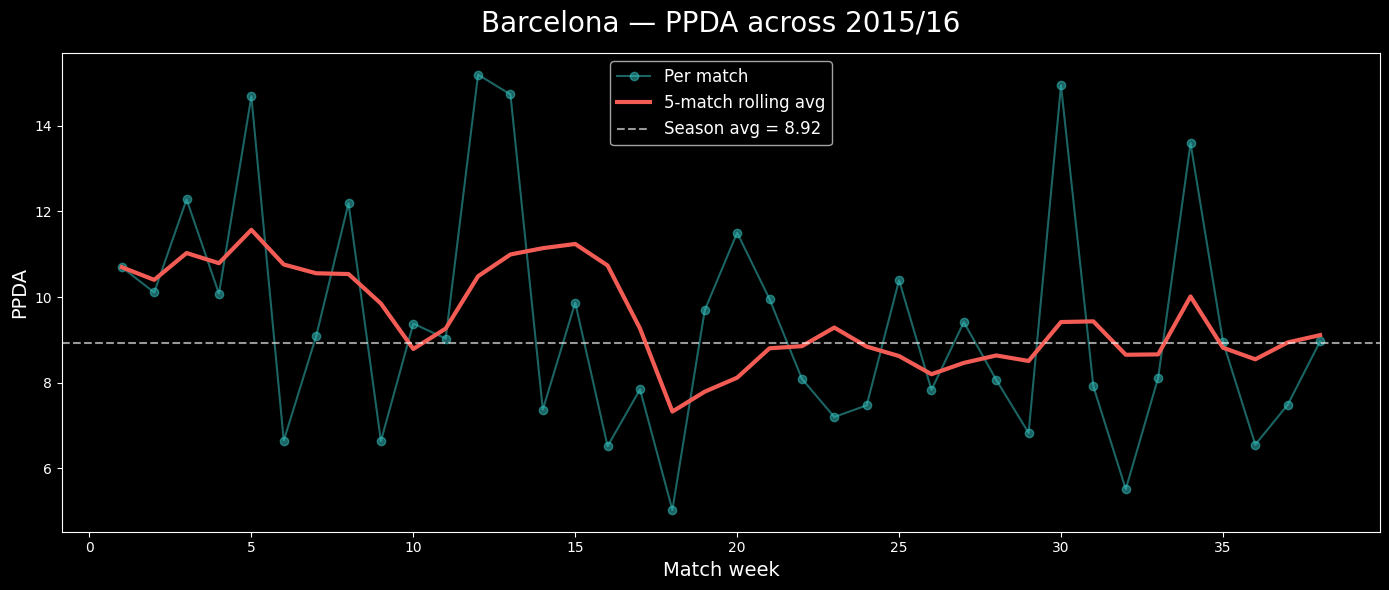

In [8]:
barca = (
    team_match[team_match["team"] == FOCAL_TEAM]
    .merge(matches[["match_id", "match_week"]], on="match_id")
    .sort_values("match_week")
)
barca["rolling"] = barca["ppda"].rolling(5, min_periods=1).mean()
season_ppda = team_season.loc[team_season["team"] == FOCAL_TEAM, "ppda"].iloc[0]

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(barca["match_week"], barca["ppda"], "o-", color="#36c9c6", alpha=0.5, label="Per match")
ax.plot(barca["match_week"], barca["rolling"], color="#f25c54", lw=3, label="5-match rolling avg")
ax.axhline(season_ppda, color="white", ls="--", alpha=0.6, label=f"Season avg = {season_ppda:.2f}")
ax.set_xlabel("Match week", fontsize=14)
ax.set_ylabel("PPDA", fontsize=14)
ax.set_title(f"{FOCAL_TEAM} — PPDA across 2015/16", fontsize=20, pad=15)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### When in a Match Do They Press?

Pressing also swings *within* a game. Binning every event into 15-minute windows — per half, so first-half stoppage time stays in the 30–45+ window instead of leaking into 45–60 — across all 38 Barcelona matches, we compute PPDA per window — opponent passes over Barcelona's defensive actions in that slice. A **lower bar means a more intense press**, showing the phases where Barcelona squeezed hardest versus eased off.

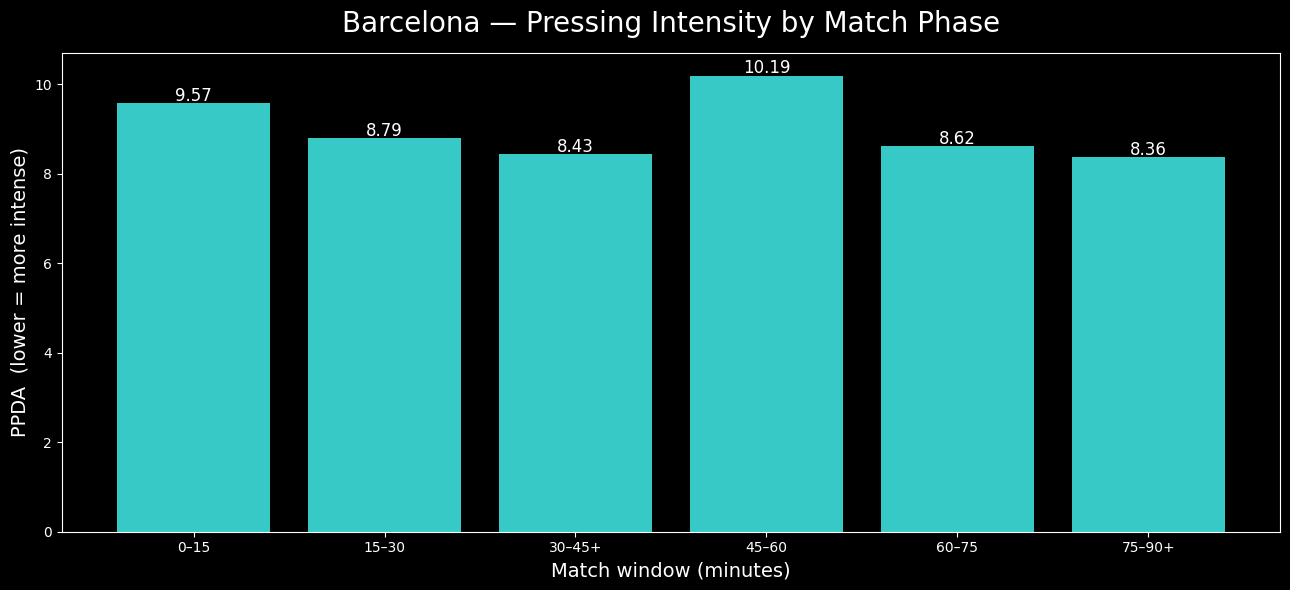

In [9]:
barca_ids = set(matches.loc[
    (matches["home"] == FOCAL_TEAM) | (matches["away"] == FOCAL_TEAM), "match_id"
])
be = events[events["match_id"].isin(barca_ids)].copy()

labels = ["0–15", "15–30", "30–45+", "45–60", "60–75", "75–90+"]
# bin per half: H1 stoppage stays in 30–45+, H2 minutes start at 45
h1 = pd.cut(be["minute"], bins=[0, 15, 30, np.inf], labels=labels[:3], right=False)
h2 = pd.cut(be["minute"].clip(lower=45), bins=[45, 60, 75, np.inf], labels=labels[3:], right=False)
be["window"] = pd.Categorical(
    np.where(be["period"] == 1, h1.astype(str), h2.astype(str)),
    categories=labels, ordered=True,
)

num = be[(be["team"] != FOCAL_TEAM) & be["pass_in_zone"]].groupby("window", observed=True).size()
den = be[(be["team"] == FOCAL_TEAM) & be["def_action_in_zone"]].groupby("window", observed=True).size()
ppda_window = (num / den).reindex(labels)

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(ppda_window.index, ppda_window.values, color="#36c9c6")
ax.set_xlabel("Match window (minutes)", fontsize=14)
ax.set_ylabel("PPDA  (lower = more intense)", fontsize=14)
ax.set_title(f"{FOCAL_TEAM} — Pressing Intensity by Match Phase", fontsize=20, pad=15)
for i, v in enumerate(ppda_window.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=12)
plt.tight_layout()
plt.show()

### What's Next?

PPDA here is the classic ratio over a fixed zone. Natural extensions:

- **Possession-adjusted (PAdj).** Normalize the denominator by the opponent's possession share, so a team that rarely has the ball isn't flattered.
- **Pressure-based PPDA.** Fold StatsBomb `Pressure` events into the denominator to capture pressing that forces a rushed pass without winning the ball.
- **Opponent-strength context.** Allowing few passes against a weak side differs from doing so against a possession monster; adjusting for opponent quality turns PPDA into a fairer measure of pressing effectiveness.